In [14]:
import numpy as np
import matplotlib.pyplot as plt
import adi

## SDR Configuration

In [17]:
# From PySDR
sample_rate = 1e6 # Hz
center_freq = 925e6 # Hz
num_samps = 1000000 # number of samples per call to rx()

sdr = adi.Pluto("ip:192.168.3.1")
sdr.sample_rate = int(sample_rate)

#################################################
# Config Tx
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -30 # Increase to increase tx power, valid range is -90 to 0 dB

##########################################
# Config Rx
sdr.rx_lo = int(center_freq)
sdr.rx_rf_bandwidth = int(sample_rate)
sdr.rx_buffer_size = num_samps

# sdr.gain_control_mode_chan0 = 'manual'
# sdr.rx_hardwaregain_chan0 = 70 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

sdr.gain_control_mode_chan0 = 'slow_attack'

## Task 1: Generate Sine Wave and Plot

[0.         0.00236234 0.00937317 ... 0.02080586 0.00937317 0.00236234]


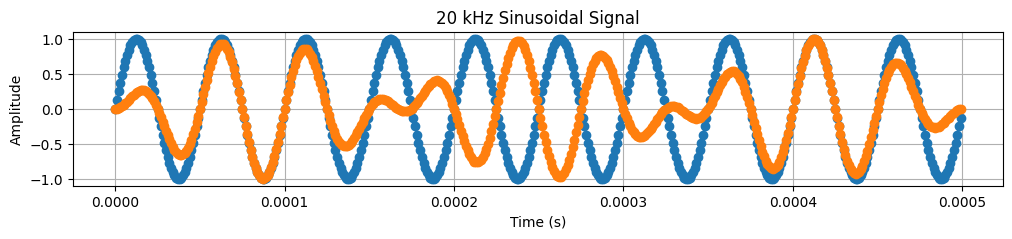

In [76]:

# Parameters
sample_rate = 1e6  # 1 MHz sample rate
duration = 0.01  # 10 ms duration
frequency = 20e3  # 1 kHz sinusoids

# Generate time vector
t = np.arange(0, duration, 1/sample_rate)

# Generate 1 kHz sinusoidal signal
signal = np.sin(2 * np.pi * frequency * t)

signal2 = np.sin(2 * np.pi *  3e3* t)

res = np.multiply(signal, signal2)
print(res)
plt.figure(figsize=(12, 2))
plt.plot(t[:500], signal[:500], 'o-')
plt.plot(t[:500], res[:500], 'o-')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('20 kHz Sinusoidal Signal')
plt.grid(True)
plt.show()

## Task 2: Plot PSD of input signal Sine Wave

20052.00520052004


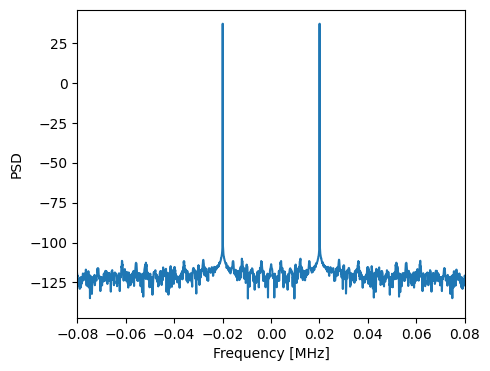

In [19]:
# Calculate power spectral density (frequency domain version of signal of Tx)
psd = np.abs(np.fft.fftshift(np.fft.fft(signal)))
psd_dB = 10*np.log10(psd)
f = np.linspace(sample_rate/-2, sample_rate/2, len(psd))

max_psd_freq = f[np.argmax(psd)]
print(max_psd_freq)

# Plot freq domain
plt.figure(1,figsize=(5,4))
plt.plot(f/1e6, psd_dB)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD")
plt.xlim(-0.08, 0.08)
plt.show()


## Task 3: Transmit and Receive in same SDR

In [20]:
# Parameters
sample_rate = 1e6  # 1 MHz sample rate
duration = 0.01  # 10 ms duration
frequency = 20e3  # 1 kHz sinusoid

# Generate time vector
t = np.arange(0, duration, 1/sample_rate)

# Generate 1 kHz sinusoidal signal
signal = np.sin(2 * np.pi * frequency * t)

# Normalize to PlutoSDR range
tx_signal = signal * 2**14

# Start the transmitter
sdr.tx_cyclic_buffer = True  # Enable cyclic buffers
sdr.tx(tx_signal)  # Start transmitting

###################################################
# Clear buffer just to be safe
# for i in range(0, 10):
#     raw_data = sdr.rx()

# Receive samples
rx_samples = sdr.rx()
print(rx_samples)

# Stop transmitting
sdr.tx_destroy_buffer()

[664.+498.j 664.+495.j 654.+488.j ... 517.+454.j 543.+475.j 562.+491.j]


### Task 4: Plot Transmitted and Received Real signal

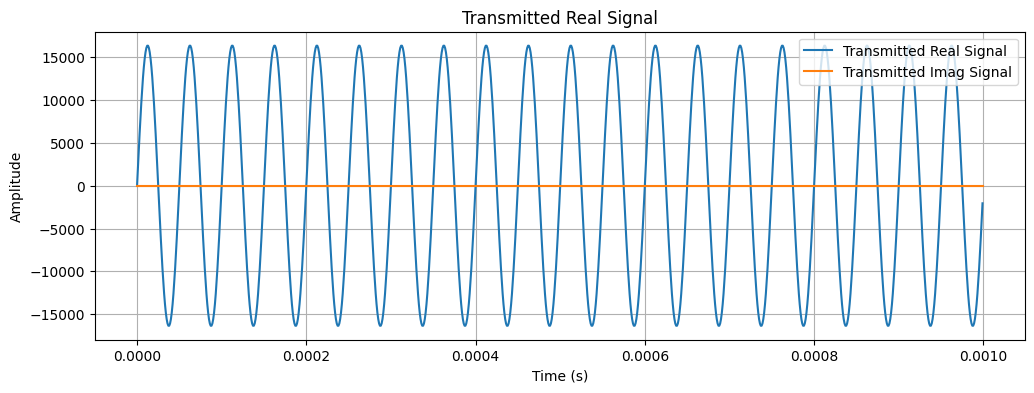

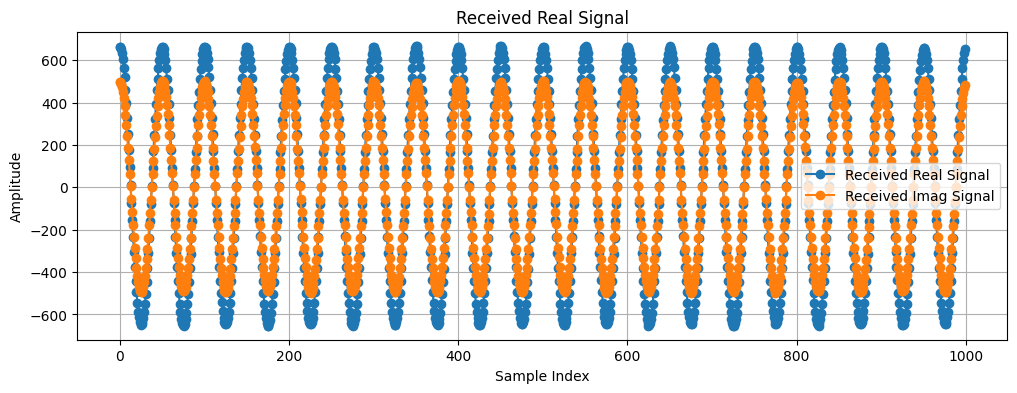

In [21]:
# Plotting transmitted real signal
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], np.real(tx_signal)[:1000], label='Transmitted Real Signal')
plt.plot(t[:1000], np.imag(tx_signal)[:1000], label='Transmitted Imag Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Transmitted Real Signal')
plt.grid(True)
plt.legend()
plt.show()

# Plotting received real signal
plt.figure(figsize=(12, 4))
plt.plot(np.real(rx_samples)[:1000], 'o-', label='Received Real Signal')
plt.plot(np.imag(rx_samples)[:1000], 'o-', label='Received Imag Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received Real Signal')
plt.grid(True)
plt.legend()
plt.show()

### Task 7: Plot PSD of Received Signal and identify the Frequency offset

-19999.51999951998


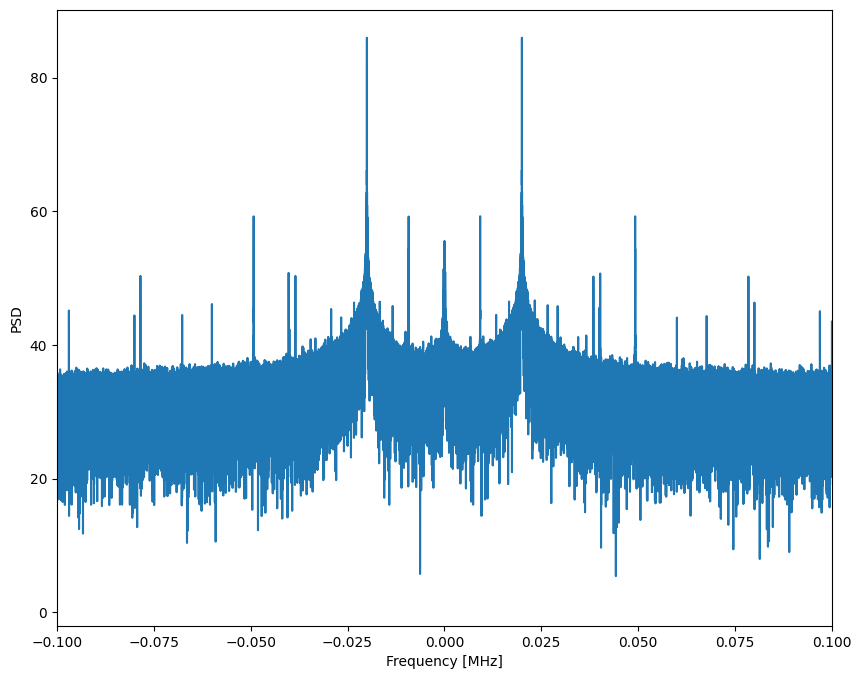

In [28]:
# Calculate power spectral density of recieved signal
psd = np.abs(np.fft.fftshift(np.fft.fft(rx_samples)))
psd_dB = 10*np.log10(psd)
f = np.linspace(sample_rate/-2, sample_rate/2, len(psd))

max_freq = f[np.argmax(psd)]
print(max_freq)

# Plot freq domain
plt.figure(1,figsize=(10,8))
plt.plot(f/1e6, psd_dB)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD")
plt.xlim(-0.1, 0.1)
plt.show()

# Transmit and Receive in 2 different SDRs

## If you transmitting - Do this one SDR



In [29]:

import numpy as np
import matplotlib.pyplot as plt
import adi

[790. -10.j 844. -20.j 893. -24.j ... -17.+317.j -27.+355.j -37.+392.j]


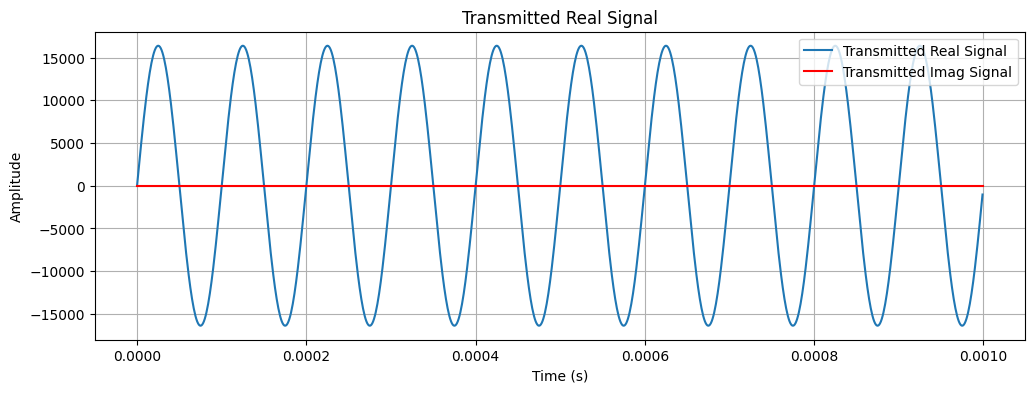

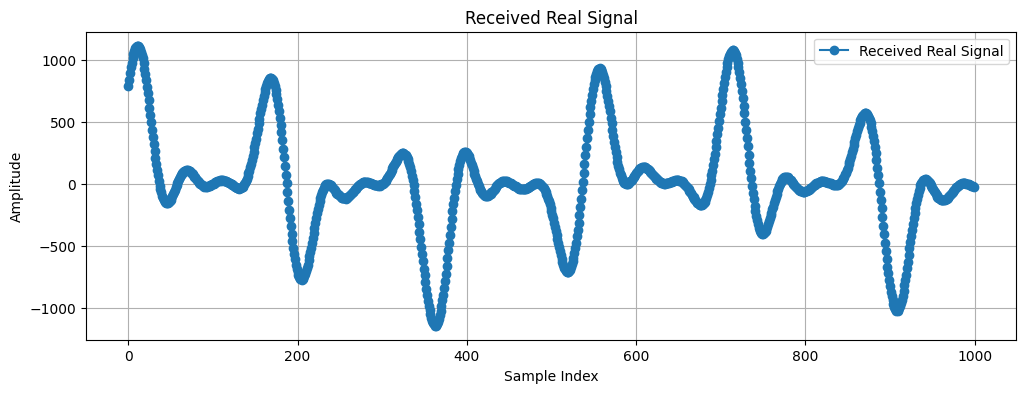

In [73]:
# From PySDR
sample_rate = 1e6 # Hz
center_freq = 925e6 # Hz
num_samps = 1000000 # number of samples per call to rx()

sdr = adi.Pluto("ip:192.168.3.1")
sdr.sample_rate = int(sample_rate)
# Config Tx
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -10 # Increase to increase tx power, valid range is -90 to 0 dB

# Parameters
sample_rate = 1e6  # 1 MHz sample rate
duration = 0.01  # 10 ms duration
frequency = 10e3  # 1 kHz sinusoids
t = np.arange(0, duration, 1/sample_rate)
signal = np.sin(2 * np.pi * frequency * t)

# Normalize to PlutoSDR range
tx_signal = signal * 2**14
# Start the transmitter
sdr.tx_cyclic_buffer = True  # Enable cyclic buffers
sdr.tx(tx_signal)  # Start transmitting

##########################################
# Config Rx
sample_rate = 1e6 # Hz
num_samps = 1000000 # number of samples per call to rx()
sdr2 = adi.Pluto("ip:192.168.2.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(center_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps

# sdr2.gain_control_mode_chan0 = 'manual'
# sdr2.rx_hardwaregain_chan0 = 70 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

sdr2.gain_control_mode_chan0 = 'slow_attack'

# Receive samples
rx_samples = sdr2.rx()
print(rx_samples)


# Plotting transmitted real signal
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], np.real(tx_signal)[:1000], label='Transmitted Real Signal')
plt.plot(t[:1000], np.imag(tx_signal)[:1000], label='Transmitted Imag Signal', color = 'red')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Transmitted Real Signal')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.real(rx_samples)[:1000], 'o-', label='Received Real Signal')
# plt.plot(np.imag(rx_samples)[:1000], 'o-', label='Received Imag Signal', color = 'red')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received Real Signal')
plt.grid(True)
plt.legend()
plt.show()


-7191.507191507204


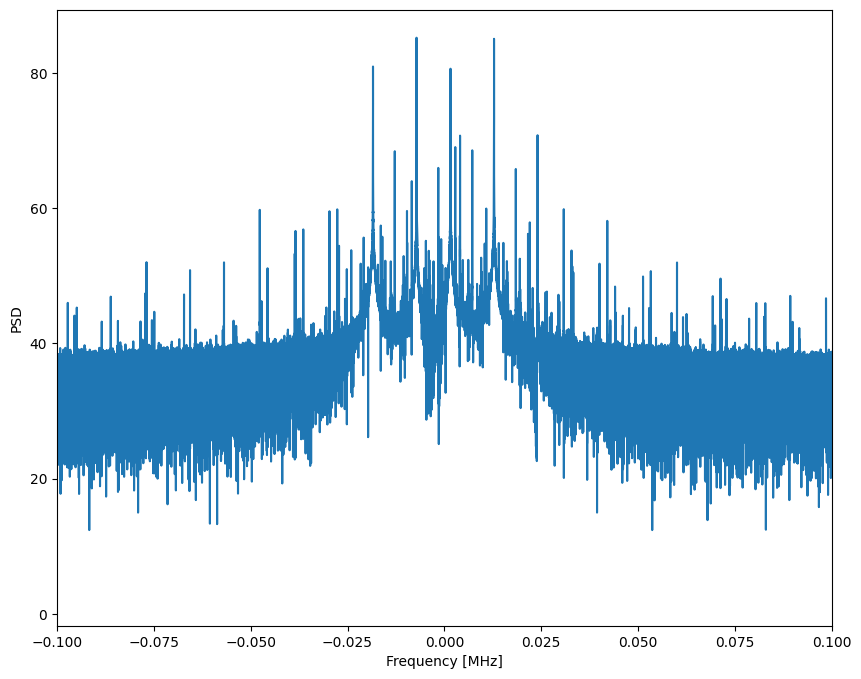

In [74]:
# Calculate power spectral density of recieved signal
psd = np.abs(np.fft.fftshift(np.fft.fft(rx_samples)))
psd_dB = 10*np.log10(psd)
f = np.linspace(sample_rate/-2, sample_rate/2, len(psd))

max_freq = f[np.argmax(psd)]
print(max_freq)

# Plot freq domain
plt.figure(1,figsize=(10,8))
plt.plot(f/1e6, psd_dB)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD")
plt.xlim(-0.1, 0.1)
plt.show()

[ 189.-499.j -147.+349.j -205.+587.j ... -694.-178.j  489.+136.j
  787.+177.j]


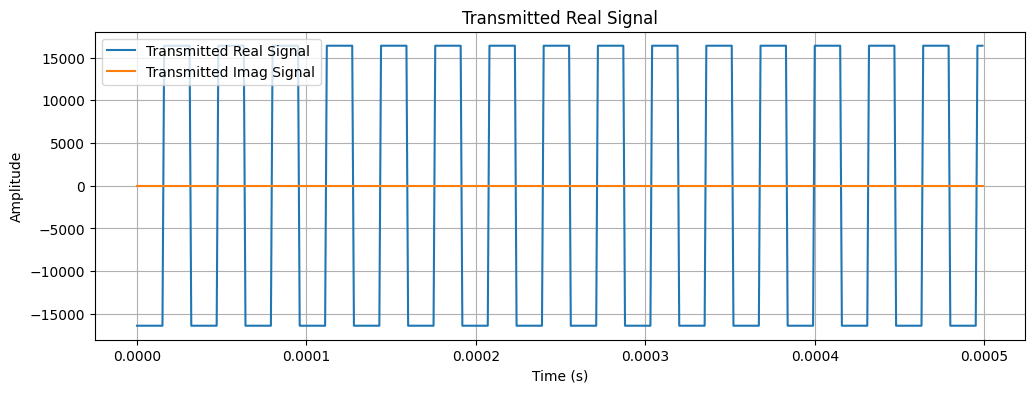

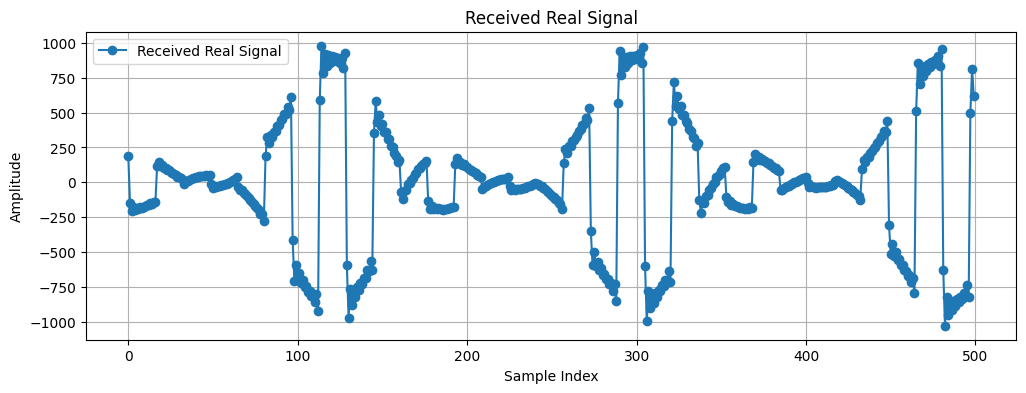

In [72]:
# From PySDR
sample_rate = 1e6 # Hz
center_freq = 925e6 # Hz
num_samps = 1000000 # number of samples per call to rx()

sdr = adi.Pluto("ip:192.168.3.1")
sdr.sample_rate = int(sample_rate)
# Config Tx
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -10 # Increase to increase tx power, valid range is -90 to 0 dB

fs = 1e6          # sample rate
t_total = 10e-3   # 10 ms
samples_per_symbol = 16
# Total samples
N = int(fs * t_total)
# Time axis
t = np.arange(N) / fs
# Generate square wave
symbols = np.arange(N // samples_per_symbol)
sq_symbols = ((symbols % 2) * 2 - 1)   # alternates between -1 and +1
signal = np.repeat(sq_symbols, samples_per_symbol)


# Normalize to PlutoSDR range
tx_signal = signal * 2**14
# Start the transmitter
sdr.tx_cyclic_buffer = True  # Enable cyclic buffers
sdr.tx(tx_signal)  # Start transmitting

##########################################
# Config Rx
sample_rate = 1e6 # Hz
num_samps = 1000000 # number of samples per call to rx()
sdr2 = adi.Pluto("ip:192.168.2.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(center_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps

# sdr2.gain_control_mode_chan0 = 'manual'
# sdr2.rx_hardwaregain_chan0 = 70 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

sdr2.gain_control_mode_chan0 = 'slow_attack'

# Receive samples
rx_samples = sdr2.rx()
print(rx_samples)


# Plotting transmitted real signal
plt.figure(figsize=(12, 4))
plt.plot(t[:500], np.real(tx_signal)[:500], label='Transmitted Real Signal')
plt.plot(t[:500], np.imag(tx_signal)[:500], label='Transmitted Imag Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Transmitted Real Signal')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.real(rx_samples)[:500], 'o-', label='Received Real Signal')
# plt.plot(np.imag(rx_samples)[:1000], 'o-', label='Received Imag Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received Real Signal')
plt.grid(True)
plt.legend()
plt.show()